# 卷积神经网络 (CNN) 前向传播全过程推演与可视化
本 Notebook 将一步步解析给定的 $5 \times 5$ 输入矩阵如何通过特征提取网络（Conv, MaxPool, AvgPool）和分类网络（FC, Softmax），最终得到分类概率。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置可视化显示参数
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

def plot_feature_map(matrix, title, cmap='Blues'):
    plt.figure(figsize=(4, 3))
    sns.heatmap(matrix, annot=True, fmt='.4g', cmap=cmap, cbar=False, 
                linewidths=1, linecolor='black', square=True)
    plt.title(title, pad=10)
    plt.xticks([])
    plt.yticks([])
    plt.show()

## 0. 底层算子定义
为了展示详细过程，我们手动定义 2D 卷积、最大池化、平均池化以及 ReLU 和 Softmax 函数。

In [2]:
def conv2d(X, W, padding=0, stride=1):
    if padding > 0:
        X = np.pad(X, pad_width=padding, mode='constant', constant_values=0)
    h, w = X.shape
    kh, kw = W.shape
    out_h = (h - kh) // stride + 1
    out_w = (w - kw) // stride + 1
    out = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            out[i, j] = np.sum(X[i*stride:i*stride+kh, j*stride:j*stride+kw] * W)
    return out

def relu(X):
    return np.maximum(0, X)

def maxpool2d(X, kernel_size=2, stride=1):
    h, w = X.shape
    out_h = (h - kernel_size) // stride + 1
    out_w = (w - kernel_size) // stride + 1
    out = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            out[i, j] = np.max(X[i*stride:i*stride+kernel_size, j*stride:j*stride+kernel_size])
    return out

def avgpool2d(X, kernel_size=4, stride=1):
    h, w = X.shape
    out_h = (h - kernel_size) // stride + 1
    out_w = (w - kernel_size) // stride + 1
    out = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            out[i, j] = np.mean(X[i*stride:i*stride+kernel_size, j*stride:j*stride+kernel_size])
    return out

def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z)) # 防止指数溢出
    return exp_Z / np.sum(exp_Z)

## 1. 原始输入数据初始化

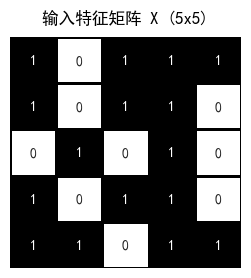

In [3]:
X = np.array([
    [1, 0, 1, 1, 1],
    [1, 0, 1, 1, 0],
    [0, 1, 0, 1, 0],
    [1, 0, 1, 1, 0],
    [1, 1, 0, 1, 1]
])
plot_feature_map(X, '输入特征矩阵 X (5x5)', cmap='Greys')

## 2. 第一层：Conv1 + ReLU1
使用给定的 $3 \times 3$ 卷积核，设置 `padding=1` 和 `stride=1`。由于填充了 1 圈 0，步长为 1，经过卷积后输出的特征图尺寸依然是 $5 \times 5$。

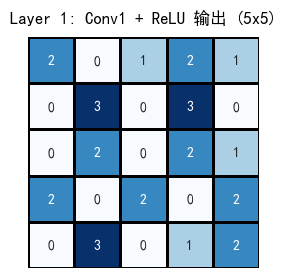

In [4]:
W_conv1 = np.array([
    [1, -1, 1],
    [0,  1, 0],
    [0,  1, -1]
])

# 卷积计算与激活
C1 = conv2d(X, W_conv1, padding=1, stride=1)
A1 = relu(C1)

plot_feature_map(A1, 'Layer 1: Conv1 + ReLU 输出 (5x5)', cmap='Blues')

## 3. 第二层：MaxPooling1
使用 $2 \times 2$ 池化核，步长为 `stride=1`（注意，常见的池化步长通常为 2，但题目设定为 1）。
输出尺寸计算公式：$\lfloor(5 - 2) / 1\rfloor + 1 = 4$。因此输出为 $4 \times 4$。

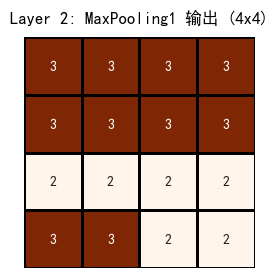

In [5]:
P1 = maxpool2d(A1, kernel_size=2, stride=1)
plot_feature_map(P1, 'Layer 2: MaxPooling1 输出 (4x4)', cmap='Oranges')

## 4. 第三层：Conv2 + ReLU2 (双通道)
输入为上一层的 $4 \times 4$ 矩阵。使用两个 $3 \times 3$ 的卷积核 $W_1$ 和 $W_2$，`padding=1`, `stride=1`。这一层将提取出两个独立通道的特征图，尺寸同样保持为 $4 \times 4$。

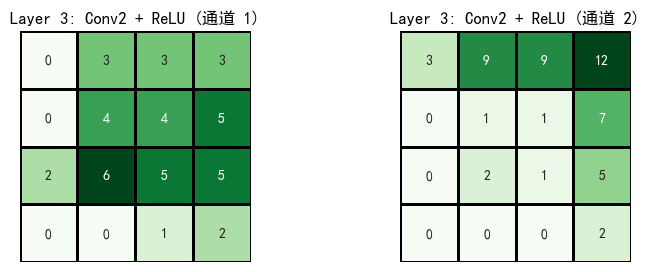

In [6]:
W_conv2_1 = np.array([
    [1,  0,  0],
    [1, -1, -1],
    [0,  1,  1]
])

W_conv2_2 = np.array([
    [0, -1, -1],
    [1,  1, -1],
    [1,  1,  0]
])

C2_1 = conv2d(P1, W_conv2_1, padding=1, stride=1)
A2_1 = relu(C2_1)

C2_2 = conv2d(P1, W_conv2_2, padding=1, stride=1)
A2_2 = relu(C2_2)

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
sns.heatmap(A2_1, annot=True, fmt='.4g', cmap='Greens', cbar=False, ax=axes[0], linewidths=1, linecolor='black', square=True)
axes[0].set_title('Layer 3: Conv2 + ReLU (通道 1)')
axes[0].axis('off')

sns.heatmap(A2_2, annot=True, fmt='.4g', cmap='Greens', cbar=False, ax=axes[1], linewidths=1, linecolor='black', square=True)
axes[1].set_title('Layer 3: Conv2 + ReLU (通道 2)')
axes[1].axis('off')
plt.show()

## 5. 第四层：AvgPooling2
对 $4 \times 4$ 的输入使用 $4 \times 4$ 的核进行平均池化（全局平均池化）。输出尺寸为 $1 \times 1$，将空间特征压缩为每个通道的一个标量。

In [7]:
pool2_1 = avgpool2d(A2_1, kernel_size=4, stride=1)[0, 0]
pool2_2 = avgpool2d(A2_2, kernel_size=4, stride=1)[0, 0]

V = np.array([pool2_1, pool2_2])
print(f"AvgPooling2 提取的特征向量 V = {V}")

AvgPooling2 提取的特征向量 V = [2.6875 3.25  ]


## 6. 全连接层 (FC) 与 Softmax
将提取的向量 $V$ 与权重矩阵进行点积。根据题图，$W_1$ 对应第一个输出节点，$W_2$ 对应第二个输出节点。

FC 层未激活输出 Z = [3.25   0.5625]

最终输出概率分布 (Softmax) = [0.9363 0.0637]


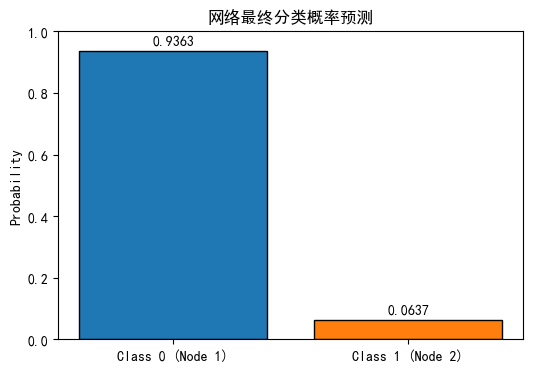

In [8]:
# FC 权重
W_fc = np.array([
    [0, -1], # W1 的列
    [1,  1]  # W2 的列
])

# 计算线性输出 Z (Z = W^T * V)
Z = np.dot(W_fc.T, V)  
print(f"FC 层未激活输出 Z = {Z}")

# Softmax 概率分布
probs = softmax(Z)
print(f"\n最终输出概率分布 (Softmax) = {np.round(probs, 4)}")

# 可视化结果
plt.figure(figsize=(6, 4))
plt.bar(['Class 0 (Node 1)', 'Class 1 (Node 2)'], probs, color=['#1f77b4', '#ff7f0e'], edgecolor='black')
plt.title('网络最终分类概率预测')
plt.ylabel('Probability')
plt.ylim(0, 1)
for i, p in enumerate(probs):
    plt.text(i, p + 0.02, f"{p:.4f}", ha='center', fontweight='bold')
plt.show()

### 结果分析总结
1. **感受野与 Padding 的作用：** 本网络在两个卷积层中都使用了 `padding=1` 和 `stride=1`。这保证了经过 $3 \times 3$ 卷积后特征图的分辨率不会立刻塌陷，使得后续能够进行更深度的特征提取。
2. **非常规的步长设计：** 通常的最大池化操作是互斥不重叠的（如 `kernel=2, stride=2`），但这道题设定的 `stride=1` 使其成为了一个**重叠池化**操作。它起到了平滑局部最值的作用，并将 $5 \times 5$ 的矩阵稳步缩小到 $4 \times 4$。
3. **全局信息整合：** 最后的 AvgPooling2（核大小与输入大小同为 $4 \times 4$）完美替代了庞大的全连接层结构，这种“全局平均池化（GAP）”策略极大减少了过拟合风险和参数量，使得 $FC$ 层仅需处理 $2$ 个标量即可完成分类。